# Stochastic Processes — Simulations

This notebook walks through the three foundational building blocks of computational finance:

| # | Model | What it answers |
|---|---|---|
| 1 | **Brownian Motion** | What does pure randomness look like? |
| 2 | **Geometric Brownian Motion** | How do asset prices evolve? |
| 3 | **Monte Carlo** | What is the average outcome under uncertainty? |

Each section shows both the math and the simulation, and verifies key theoretical properties empirically.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm
import sys
from pathlib import Path

# Notebook lives at src/stochastic_processes/simulations.ipynb
# So we need to add src/ to the path (two levels up from here)
SRC_DIR = Path('__file__').resolve().parent.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Also add the stochastic_processes folder itself for local imports
THIS_DIR = Path('__file__').resolve().parent
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

from brownian_motion import simulate_brownian_motion
from geometric_bm import simulate_gbm

print('Imports OK')

Imports OK


---
## 1 — Brownian Motion

Brownian motion (Wiener process) models **pure accumulated randomness** over time.

**Definition:** A process $W(t)$ is a standard Brownian motion if:
- $W(0) = 0$
- Increments $dW = W(t+dt) - W(t) \sim \mathcal{N}(0,\, dt)$
- Increments are independent across time
- Paths are continuous but nowhere differentiable

**Key property:** $\text{Var}[W(t)] = t$ — uncertainty grows linearly with time.

In finance, Brownian motion is **not** a price model. It is the raw noise engine that drives GBM, Black-Scholes, and all stochastic volatility models.

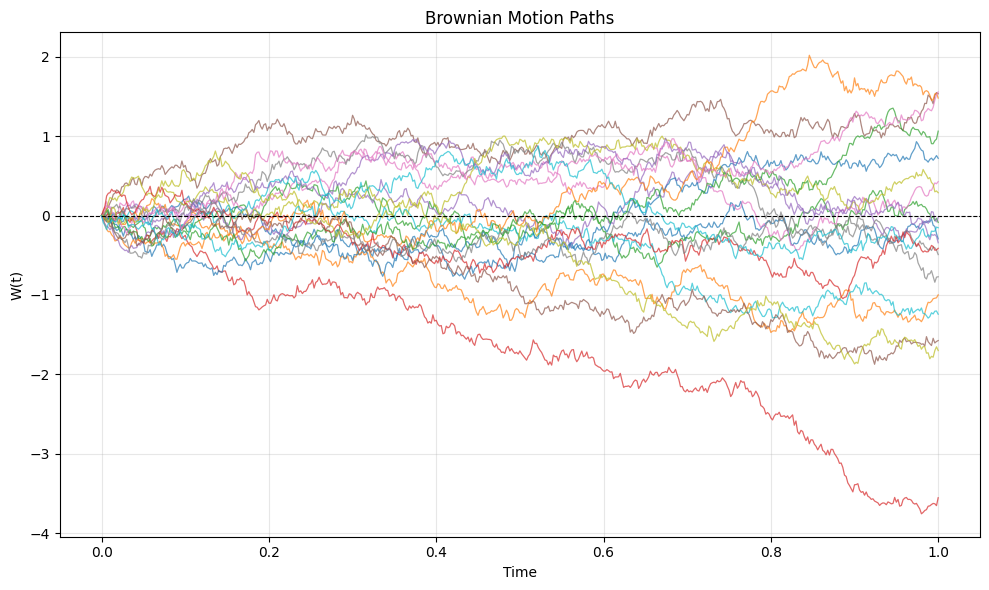

In [3]:
# ---- Simulate Brownian motion paths ----
T, N, n_paths = 1.0, 500, 20
t, W = simulate_brownian_motion(T=T, N=N, n_paths=n_paths, seed=42)

plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(t, W[i], alpha=0.7, linewidth=0.9)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Brownian Motion Paths')
plt.xlabel('Time')
plt.ylabel('W(t)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**What to notice:**
- All paths start at 0
- Paths spread out as time increases — no drift, no trend
- Some go up, some go down — pure randomness
- The spread (uncertainty) grows over time

### 1a — Verifying Var[W(t)] = t

The most important theoretical property: variance grows **linearly** with time.
We can verify this empirically by computing the variance across many paths at each time step.

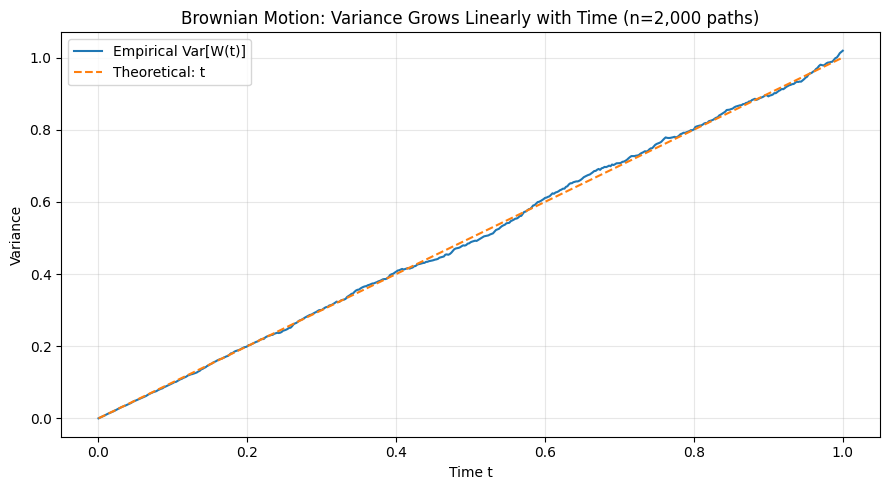

In [4]:
t_var, W_var = simulate_brownian_motion(T=1.0, N=500, n_paths=2000, seed=0)

empirical_var = W_var.var(axis=0)

plt.figure(figsize=(9, 5))
plt.plot(t_var, empirical_var, label='Empirical Var[W(t)]', linewidth=1.5)
plt.plot(t_var, t_var, label='Theoretical: t', linestyle='--', linewidth=1.5)
plt.xlabel('Time t')
plt.ylabel('Variance')
plt.title('Brownian Motion: Variance Grows Linearly with Time (n=2,000 paths)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1b — Increments are Normally Distributed

Each increment $dW \sim \mathcal{N}(0, dt)$. This is the Gaussian noise assumption that underlies all of Black-Scholes theory.

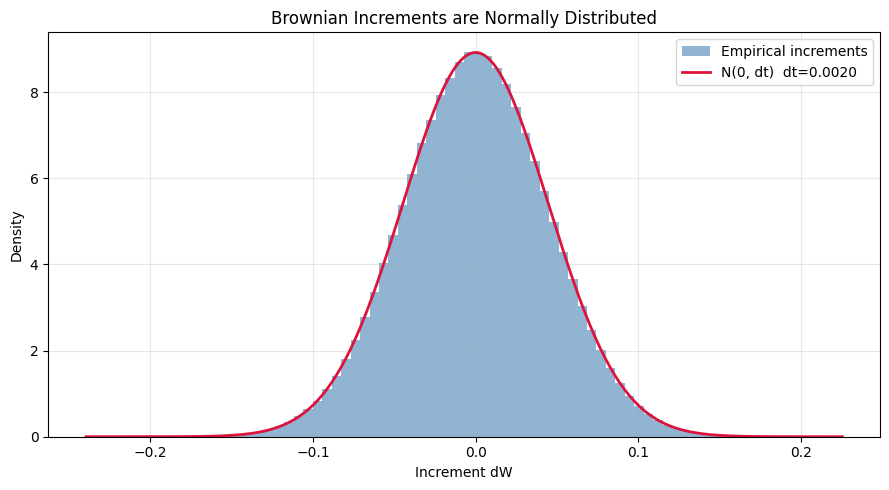

In [5]:
t_inc, W_inc = simulate_brownian_motion(T=1.0, N=500, n_paths=5000, seed=1)
dt = 1.0 / 500
increments = np.diff(W_inc, axis=1).flatten()

x = np.linspace(increments.min(), increments.max(), 300)
theoretical = norm.pdf(x, loc=0, scale=np.sqrt(dt))

plt.figure(figsize=(9, 5))
plt.hist(increments, bins=80, density=True, alpha=0.6, color='steelblue', label='Empirical increments')
plt.plot(x, theoretical, color='crimson', linewidth=2, label=f'N(0, dt)  dt={dt:.4f}')
plt.xlabel('Increment dW')
plt.ylabel('Density')
plt.title('Brownian Increments are Normally Distributed')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1c — Spread Grows with Time Horizon

Longer time horizons produce wider path fans. Uncertainty accumulates as $\sqrt{T}$.

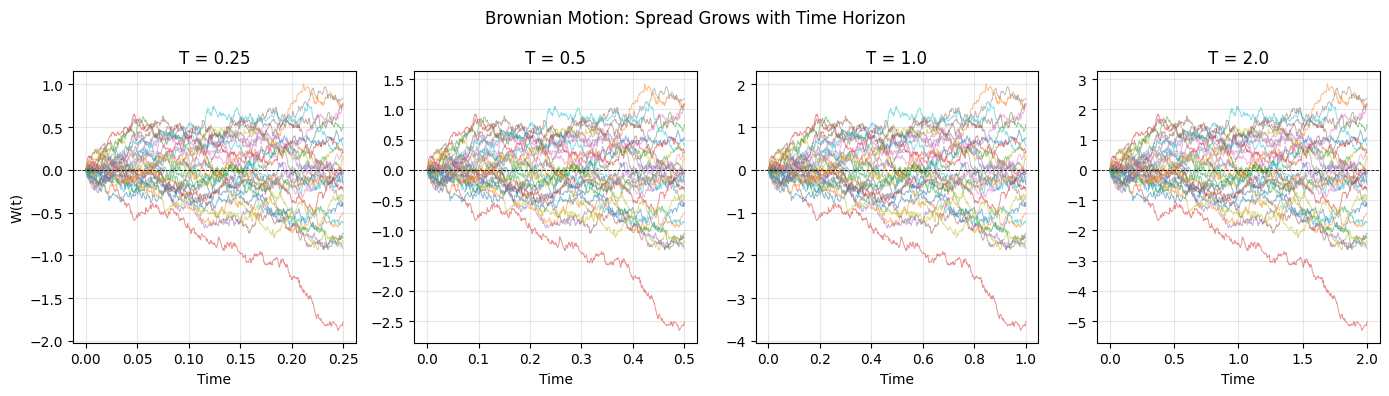

In [6]:
horizons = [0.25, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, T_h in zip(axes, horizons):
    t_h, W_h = simulate_brownian_motion(T=T_h, N=500, n_paths=30, seed=42)
    for i in range(W_h.shape[0]):
        ax.plot(t_h, W_h[i], alpha=0.5, linewidth=0.7)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f'T = {T_h}')
    ax.set_xlabel('Time')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('W(t)')
plt.suptitle('Brownian Motion: Spread Grows with Time Horizon', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2 — Geometric Brownian Motion (GBM)

GBM models **asset prices** — not raw randomness. It wraps Brownian motion in an exponential so prices stay positive and compound naturally.

**SDE:**
$$dS = \mu S\, dt + \sigma S\, dW$$

**Exact solution** (via Itô's lemma):
$$S(t) = S_0 \cdot \exp\!\left[\left(\mu - \tfrac{1}{2}\sigma^2\right)t + \sigma W(t)\right]$$

**Parameters:**
- $\mu$ — drift (expected return per year)
- $\sigma$ — volatility (std of log returns per year)

**Key properties:**
- $S(t) > 0$ always (prices never go negative)
- Log returns are normally distributed: $\log(S(T)/S_0) \sim \mathcal{N}\!\left((\mu - \tfrac{\sigma^2}{2})T,\; \sigma^2 T\right)$
- $\mathbb{E}[S(T)] = S_0 e^{\mu T}$ (the $-\tfrac{1}{2}\sigma^2$ Itô correction is critical)

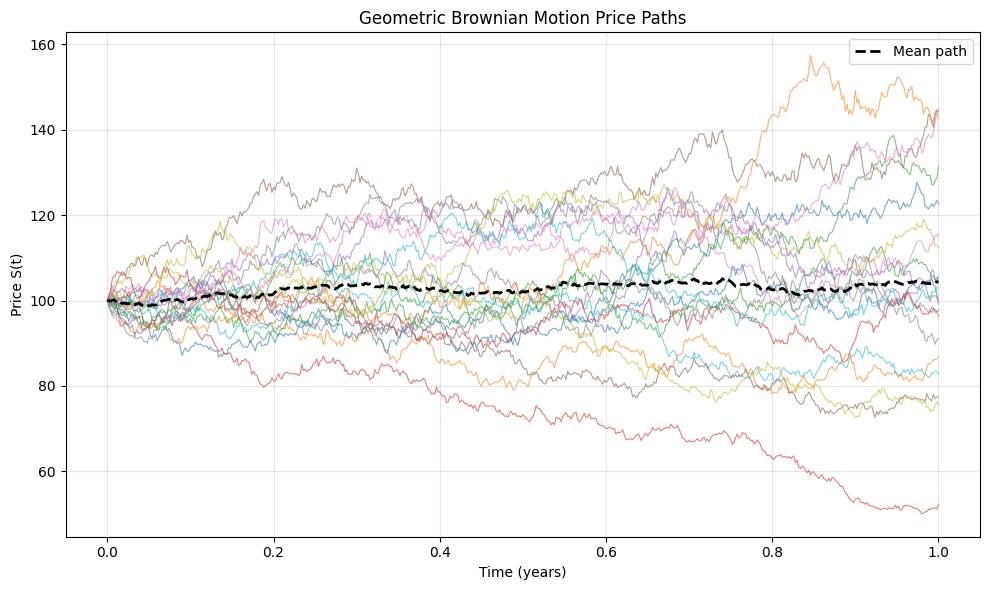

In [7]:
# ---- Base GBM paths ----
S0, mu, sigma, T, N = 100.0, 0.08, 0.2, 1.0, 500
t, S = simulate_gbm(S0=S0, mu=mu, sigma=sigma, T=T, N=N, n_paths=20, seed=42)

plt.figure(figsize=(10, 6))
for i in range(S.shape[0]):
    plt.plot(t, S[i], alpha=0.6, linewidth=0.8)
plt.plot(t, S.mean(axis=0), color='black', linewidth=2.0, linestyle='--', label='Mean path')
plt.title('Geometric Brownian Motion Price Paths')
plt.xlabel('Time (years)')
plt.ylabel('Price S(t)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2a — Log Returns are Normally Distributed

This is the testable core assumption of GBM. If log returns weren't normal, the entire Black-Scholes framework would break down.

We verify: $\log(S(T)/S_0) \sim \mathcal{N}\!\left((\mu - \tfrac{\sigma^2}{2})T,\; \sigma^2 T\right)$

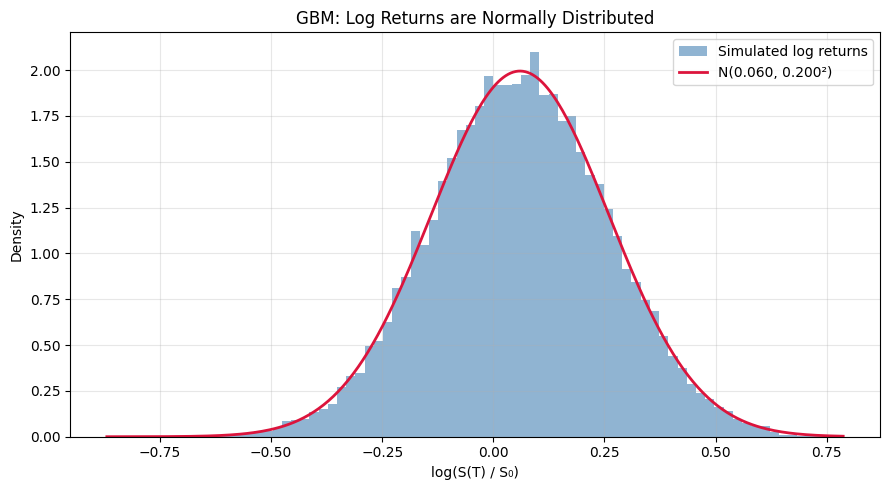

Empirical mean: 0.0596  |  Theoretical: 0.0600
Empirical std:  0.1987  |  Theoretical: 0.2000


In [8]:
S0, mu, sigma, T, N = 100.0, 0.08, 0.2, 1.0, 252
t_lr, S_lr = simulate_gbm(S0=S0, mu=mu, sigma=sigma, T=T, N=N, n_paths=20_000, seed=7)

log_returns = np.log(S_lr[:, -1] / S0)
mean_theory = (mu - 0.5 * sigma**2) * T
std_theory  = sigma * np.sqrt(T)

x = np.linspace(log_returns.min(), log_returns.max(), 300)

plt.figure(figsize=(9, 5))
plt.hist(log_returns, bins=80, density=True, alpha=0.6,
         color='steelblue', label='Simulated log returns')
plt.plot(x, norm.pdf(x, mean_theory, std_theory), color='crimson',
         linewidth=2, label=f'N({mean_theory:.3f}, {std_theory:.3f}²)')
plt.xlabel('log(S(T) / S₀)')
plt.ylabel('Density')
plt.title('GBM: Log Returns are Normally Distributed')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Empirical mean: {log_returns.mean():.4f}  |  Theoretical: {mean_theory:.4f}')
print(f'Empirical std:  {log_returns.std():.4f}  |  Theoretical: {std_theory:.4f}')

### 2b — Effect of Volatility σ

Higher σ → wider fan-out of paths → more uncertainty about where the price ends up.

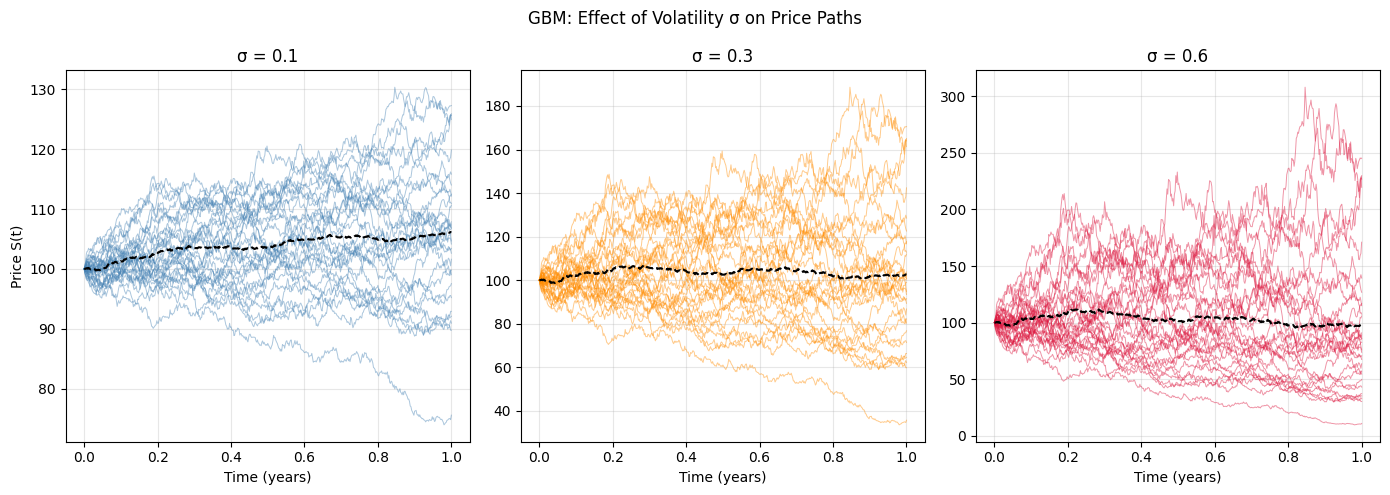

In [9]:
sigmas = [0.1, 0.3, 0.6]
colors = ['steelblue', 'darkorange', 'crimson']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, sig, color in zip(axes, sigmas, colors):
    t_s, S_s = simulate_gbm(S0=100, mu=0.08, sigma=sig, T=1.0, N=500, n_paths=30, seed=42)
    for i in range(S_s.shape[0]):
        ax.plot(t_s, S_s[i], alpha=0.45, linewidth=0.7, color=color)
    ax.plot(t_s, S_s.mean(axis=0), color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'σ = {sig}')
    ax.set_xlabel('Time (years)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Price S(t)')
plt.suptitle('GBM: Effect of Volatility σ on Price Paths', fontsize=12)
plt.tight_layout()
plt.show()

### 2c — Effect of Drift μ

μ shifts the expected price path without changing the spread. The theoretical mean is $\mathbb{E}[S(t)] = S_0 e^{\mu t}$.

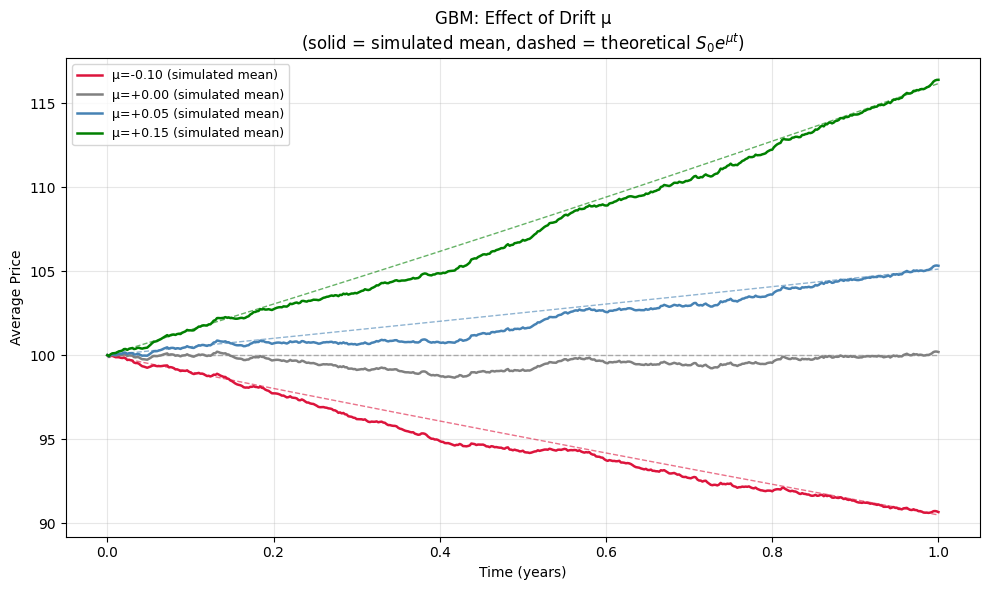

In [10]:
mus    = [-0.1, 0.0, 0.05, 0.15]
colors = ['crimson', 'gray', 'steelblue', 'green']
t_d = np.linspace(0, 1.0, 501)

plt.figure(figsize=(10, 6))
for mu_d, color in zip(mus, colors):
    _, S_d = simulate_gbm(S0=100, mu=mu_d, sigma=0.2, T=1.0, N=500, n_paths=500, seed=42)
    plt.plot(t_d, S_d.mean(axis=0), color=color, linewidth=1.8,
             label=f'μ={mu_d:+.2f} (simulated mean)')
    plt.plot(t_d, 100 * np.exp(mu_d * t_d), color=color,
             linewidth=1.0, linestyle='--', alpha=0.6)

plt.xlabel('Time (years)')
plt.ylabel('Average Price')
plt.title('GBM: Effect of Drift μ\n(solid = simulated mean, dashed = theoretical $S_0 e^{μt}$)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3 — Monte Carlo Expectation

Monte Carlo answers: **"What is the average outcome under uncertainty?"**

**Steps:**
1. Simulate many possible futures (paths)
2. Compute the quantity of interest on each path
3. Average across paths → Law of Large Numbers guarantees convergence

Monte Carlo does **not** create new models — it **extracts numerical expectations** from whatever stochastic model you feed it. This is the numerical backbone of pricing, risk, and forecasting.

### 3a — Convergence of E[S(T)]

Paths:     50 | E[S_T] ≈ 101.3103  (theoretical: 105.1271)
Paths:    100 | E[S_T] ≈ 108.2779  (theoretical: 105.1271)
Paths:    500 | E[S_T] ≈ 104.0296  (theoretical: 105.1271)
Paths:   1000 | E[S_T] ≈ 105.1406  (theoretical: 105.1271)
Paths:   5000 | E[S_T] ≈ 105.3464  (theoretical: 105.1271)
Paths:  10000 | E[S_T] ≈ 105.3157  (theoretical: 105.1271)


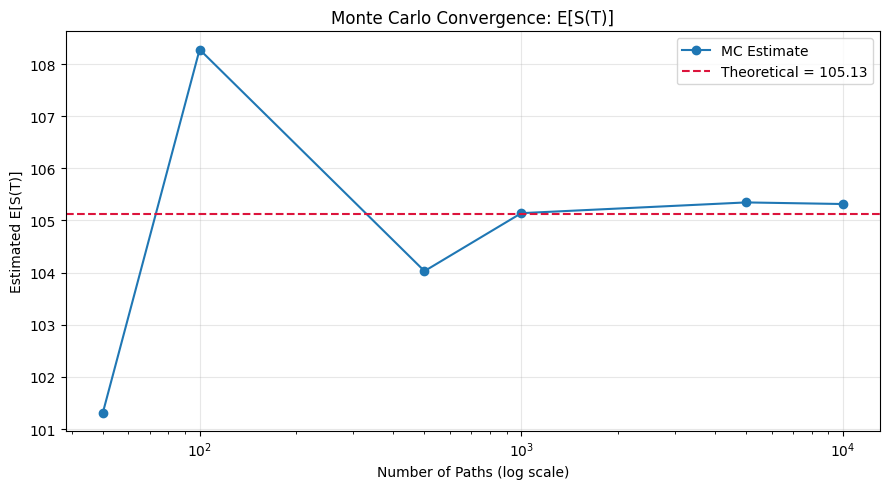

In [11]:
S0, mu, sigma, T, N = 100.0, 0.05, 0.2, 1.0, 252
theoretical = S0 * np.exp(mu * T)

path_counts = [50, 100, 500, 1_000, 5_000, 10_000]
estimates = []

for n_paths in path_counts:
    _, S_mc = simulate_gbm(S0=S0, mu=mu, sigma=sigma, T=T, N=N, n_paths=n_paths, seed=42)
    estimates.append(S_mc[:, -1].mean())
    print(f'Paths: {n_paths:>6} | E[S_T] ≈ {estimates[-1]:.4f}  (theoretical: {theoretical:.4f})')

plt.figure(figsize=(9, 5))
plt.plot(path_counts, estimates, marker='o', linewidth=1.5, label='MC Estimate')
plt.axhline(theoretical, color='crimson', linestyle='--',
            linewidth=1.5, label=f'Theoretical = {theoretical:.2f}')
plt.xscale('log')
plt.xlabel('Number of Paths (log scale)')
plt.ylabel('Estimated E[S(T)]')
plt.title('Monte Carlo Convergence: E[S(T)]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3b — Terminal Price Distribution vs Lognormal

GBM terminal prices follow a lognormal distribution. We can verify this by overlaying the theoretical PDF on the simulated histogram.

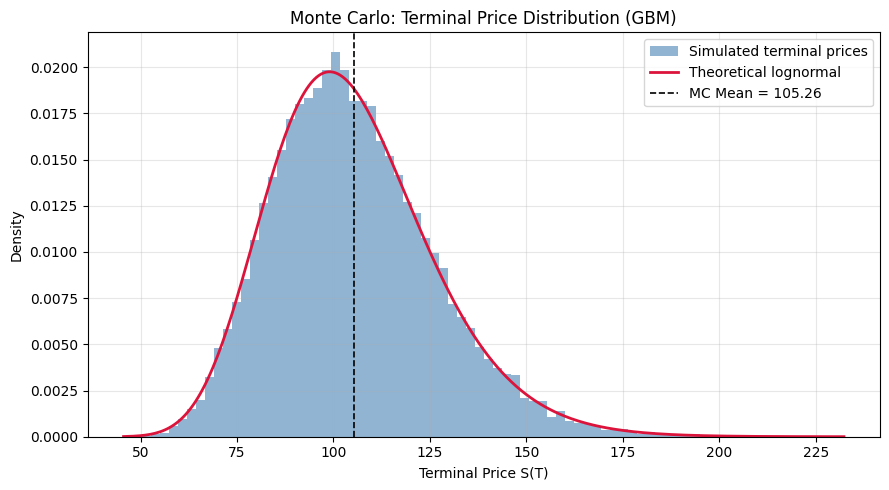

MC   E[S_T] = 105.2612  |  Theoretical = 105.1271
MC Std[S_T] = 21.1185


In [12]:
S0, mu, sigma, T, N = 100.0, 0.05, 0.2, 1.0, 252
_, S_dist = simulate_gbm(S0=S0, mu=mu, sigma=sigma, T=T, N=N, n_paths=20_000, seed=123)
S_T = S_dist[:, -1]

log_mean = np.log(S0) + (mu - 0.5 * sigma**2) * T
log_std  = sigma * np.sqrt(T)
x = np.linspace(S_T.min(), S_T.max(), 300)

plt.figure(figsize=(9, 5))
plt.hist(S_T, bins=80, density=True, alpha=0.6, color='steelblue', label='Simulated terminal prices')
plt.plot(x, lognorm.pdf(x, s=log_std, scale=np.exp(log_mean)),
         color='crimson', linewidth=2, label='Theoretical lognormal')
plt.axvline(S_T.mean(), color='black', linestyle='--',
            linewidth=1.2, label=f'MC Mean = {S_T.mean():.2f}')
plt.xlabel('Terminal Price S(T)')
plt.ylabel('Density')
plt.title('Monte Carlo: Terminal Price Distribution (GBM)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'MC   E[S_T] = {S_T.mean():.4f}  |  Theoretical = {S0 * np.exp(mu * T):.4f}')
print(f'MC Std[S_T] = {S_T.std():.4f}')

### 3c — Option Pricing via Monte Carlo

The payoff of a European call option is $\max(S(T) - K,\, 0)$.

The Monte Carlo price is the discounted expected payoff:
$$C = e^{-rT} \cdot \mathbb{E}[\max(S(T) - K,\, 0)]$$

We compare against the **Black-Scholes closed-form** to validate.

European Call  (S0=100.0, K=105.0, r=0.05, σ=0.2, T=1.0)
  MC price:    8.0190  [95% CI: 7.9029 – 8.1351]
  BS price:    8.0214
  Error:       0.0024


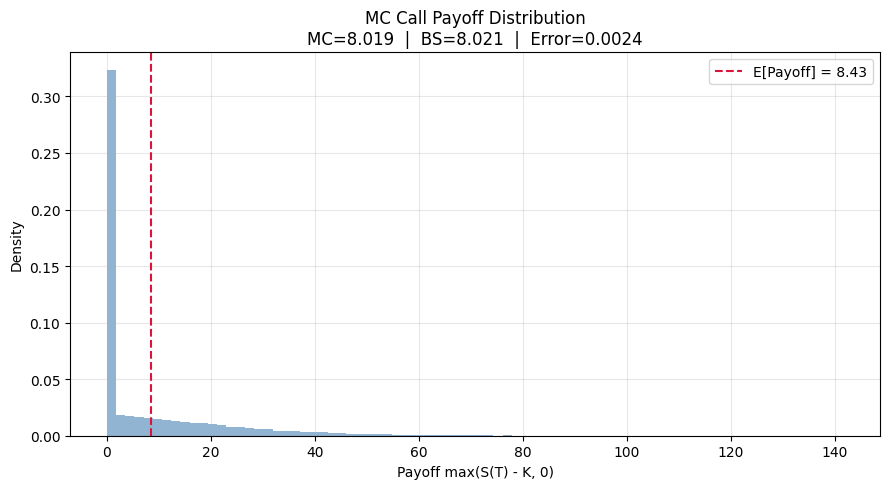

In [13]:
S0, K, r, sigma, T, N = 100.0, 105.0, 0.05, 0.2, 1.0, 252
n_paths = 50_000

_, S_opt = simulate_gbm(S0=S0, mu=r, sigma=sigma, T=T, N=N, n_paths=n_paths, seed=42)
payoffs = np.maximum(S_opt[:, -1] - K, 0)
mc_price = np.exp(-r * T) * payoffs.mean()

se    = payoffs.std() / np.sqrt(n_paths)
ci_lo = np.exp(-r * T) * (payoffs.mean() - 1.96 * se)
ci_hi = np.exp(-r * T) * (payoffs.mean() + 1.96 * se)

# Black-Scholes closed form
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print(f'European Call  (S0={S0}, K={K}, r={r}, σ={sigma}, T={T})')
print(f'  MC price:    {mc_price:.4f}  [95% CI: {ci_lo:.4f} – {ci_hi:.4f}]')
print(f'  BS price:    {bs_price:.4f}')
print(f'  Error:       {abs(mc_price - bs_price):.4f}')

plt.figure(figsize=(9, 5))
plt.hist(payoffs, bins=80, density=True, alpha=0.6, color='steelblue')
plt.axvline(payoffs.mean(), color='crimson', linestyle='--',
            linewidth=1.5, label=f'E[Payoff] = {payoffs.mean():.2f}')
plt.xlabel('Payoff max(S(T) - K, 0)')
plt.ylabel('Density')
plt.title(f'MC Call Payoff Distribution\nMC={mc_price:.3f}  |  BS={bs_price:.3f}  |  Error={abs(mc_price-bs_price):.4f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3d — Confidence Intervals Shrink as 1/√n

The standard error of a Monte Carlo estimate is $\text{SE} = \sigma / \sqrt{n}$.
This means to halve the error, you need **4× more paths** — the fundamental cost of Monte Carlo.

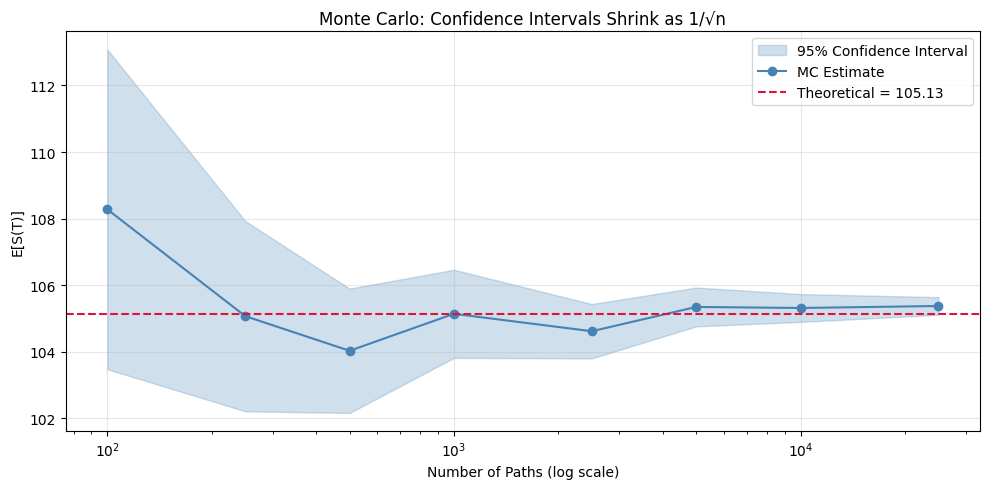

In [14]:
S0, mu, sigma, T, N = 100.0, 0.05, 0.2, 1.0, 252
theoretical = S0 * np.exp(mu * T)
path_counts_ci = [100, 250, 500, 1_000, 2_500, 5_000, 10_000, 25_000]

means, ci_los, ci_his = [], [], []

for n_paths in path_counts_ci:
    _, S_ci = simulate_gbm(S0=S0, mu=mu, sigma=sigma, T=T, N=N, n_paths=n_paths, seed=42)
    S_T_ci = S_ci[:, -1]
    m  = S_T_ci.mean()
    se = S_T_ci.std() / np.sqrt(n_paths)
    means.append(m)
    ci_los.append(m - 1.96 * se)
    ci_his.append(m + 1.96 * se)

means  = np.array(means)
ci_los = np.array(ci_los)
ci_his = np.array(ci_his)

plt.figure(figsize=(10, 5))
plt.fill_between(path_counts_ci, ci_los, ci_his, alpha=0.25,
                 color='steelblue', label='95% Confidence Interval')
plt.plot(path_counts_ci, means, marker='o', linewidth=1.5,
         color='steelblue', label='MC Estimate')
plt.axhline(theoretical, color='crimson', linestyle='--',
            linewidth=1.5, label=f'Theoretical = {theoretical:.2f}')
plt.xscale('log')
plt.xlabel('Number of Paths (log scale)')
plt.ylabel('E[S(T)]')
plt.title('Monte Carlo: Confidence Intervals Shrink as 1/√n')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

| Concept | Key Takeaway |
|---|---|
| **Brownian Motion** | Pure noise. $\text{Var}[W(t)] = t$. Increments are $\mathcal{N}(0, dt)$. Foundation of everything. |
| **GBM** | Prices = $S_0 e^{(\mu - \sigma^2/2)t + \sigma W(t)}$. Log returns are normal. Always positive. |
| **Monte Carlo** | Average over many paths. Converges at $1/\sqrt{n}$. Works for any payoff or model. |

These three ideas together form the computational core of the Black-Scholes world.

**Next:** In the `volatility_models/` folder, we relax the constant-σ assumption and see what happens when volatility itself is dynamic.